In [39]:
import pandas as pd
from scipy.stats import chisquare
from pingouin import ttest
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

### Data Loading

In [13]:
users = pd.read_csv('users_dataset_full.csv') 
sessions = pd.read_csv('sessions_dataset_full.csv')

Merging Data

In [15]:
sessions_x_users = sessions.merge(users, on = 'user_id', how = 'inner')

Calculating relative effect size

In [23]:
def estimate_effect_size(df: pd.DataFrame, metric: str) -> float:
    """
    Parameters:
    - df (pd.DataFrame): data with experiment_group ('control', 'variant') and metric columns.
    - metric (str): name of the metric column

    Returns:
    - effect_size (float): average treatment effect (effect size)
    """
    avg_metric_per_group = df.groupby('experiment_group')[metric].mean()
    effect_size = avg_metric_per_group['variant'] / avg_metric_per_group['control'] - 1
    return effect_size

confidence_level = 0.90 
alpha = 1 - confidence_level

In [33]:
# Binary conversion flag: 1 if booking occurred, 0 otherwise
sessions_x_users['conversion'] = sessions_x_users['booking_timestamp'].notnull().astype(int)

# Check if the number of users in each experiment group is balanced
groups_count = sessions_x_users['experiment_group'].value_counts()
print(groups_count)


experiment_group
variant    7653
control    7630
Name: count, dtype: int64


### EDA

CONVERSION RATE BY EXPERIMENT GROUP

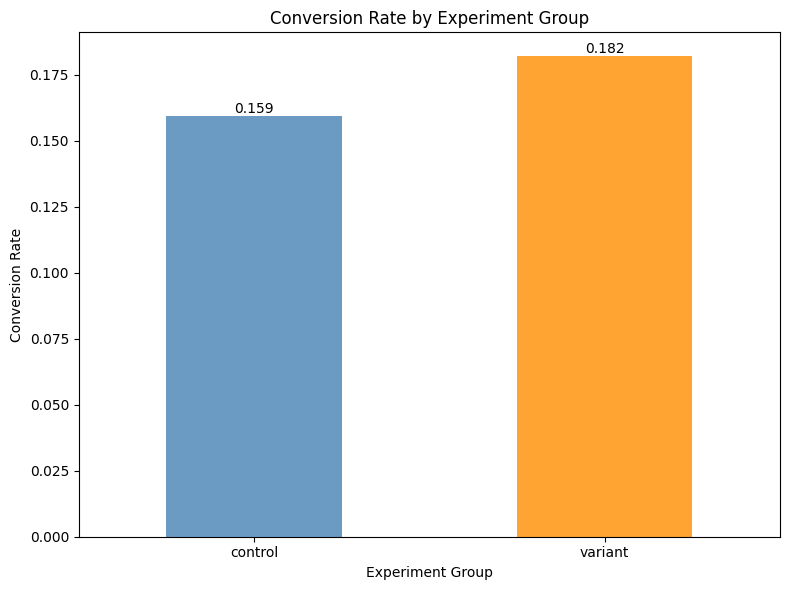

In [41]:
conversion_rates = sessions_x_users.groupby('experiment_group')['conversion'].mean()
plt.figure(figsize=(8, 6))
conversion_rates.plot(kind='bar', color=['steelblue', 'darkorange'], alpha=0.8)
plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
for i, rate in enumerate(conversion_rates):
    plt.text(i, rate, f'{rate:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("conversion_rate_by_group.png")
plt.show()

TIME TO BOOKING DISTRIBUTION (GUARDRAIL METRIC)

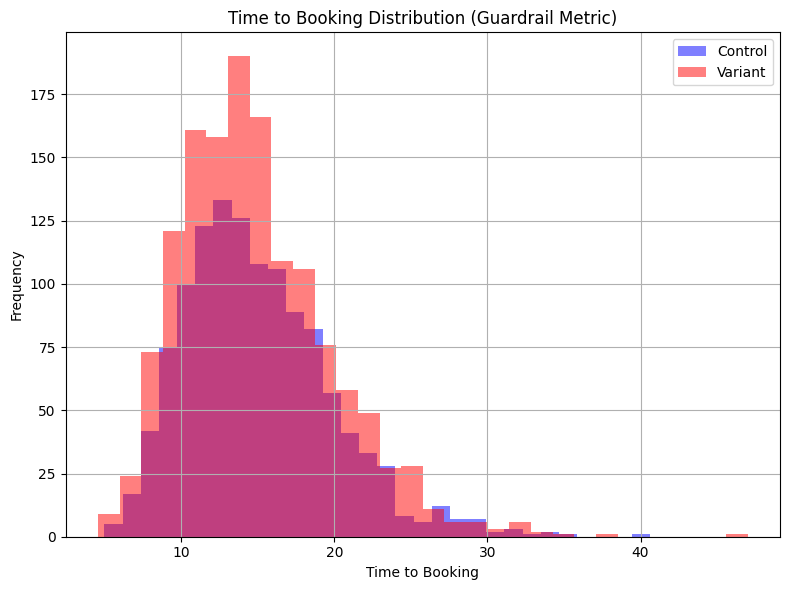

In [45]:
plt.figure(figsize=(8, 6))
sessions_x_users[sessions_x_users["experiment_group"] == "control"]["time_to_booking"].hist(
    bins=30, alpha=0.5, label="Control", color="blue")
sessions_x_users[sessions_x_users["experiment_group"] == "variant"]["time_to_booking"].hist(
    bins=30, alpha=0.5, label="Variant", color="red")
plt.title("Time to Booking Distribution (Guardrail Metric)")
plt.xlabel("Time to Booking")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("time_to_booking_distribution.png")
plt.show()

SAMPLE SIZE BY GROUP (SRM SANITY CHECK)

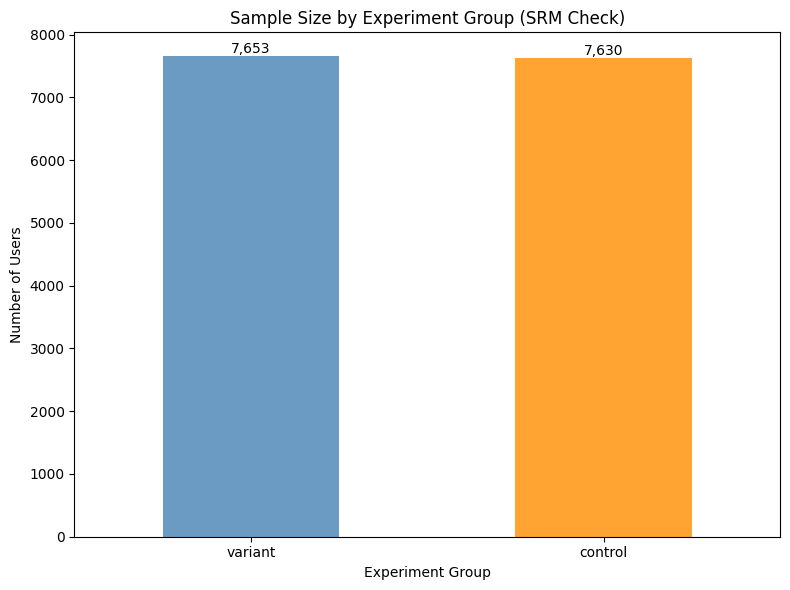

In [48]:
group_counts = sessions_x_users['experiment_group'].value_counts()
plt.figure(figsize=(8, 6))
group_counts.plot(kind='bar', color=['steelblue', 'darkorange'], alpha=0.8)
plt.title("Sample Size by Experiment Group (SRM Check)")
plt.xlabel("Experiment Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
for i, count in enumerate(group_counts):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("sample_size_by_group.png")
plt.show()

### Analysis

In [50]:
n = sessions_x_users.shape[0] # Total sample size
srm_chi2_stat, srm_chi2_pval = chisquare(f_obs = groups_count, f_exp = (n/2, n/2))
srm_chi2_pval = round(srm_chi2_pval, 4)
print(f'\nSRM\np-value: {srm_chi2_pval}') # If p < alpha, there's likely a sampling issue issue
    
# Success counts and sample sizes for each group
success_counts = sessions_x_users.groupby('experiment_group')['conversion'].sum().loc[['control', 'variant']]
sample_sizes = sessions_x_users['experiment_group'].value_counts().loc[['control', 'variant']]

# Z-test for proportions (binary conversion metric)
zstat_primary, pval_primary = proportions_ztest(
    success_counts,
    sample_sizes,
    alternative = 'two-sided',
)
pval_primary = round(pval_primary, 4)

# Effect size for the conversion metric
effect_size_primary = estimate_effect_size(sessions_x_users, 'conversion')
effect_size_primary = round(effect_size_primary, 4)
print(f'\nPrimary metric\np-value: {pval_primary: .4f} | effect size: {effect_size_primary: .4f}')
    
# EFFECT ANALYSIS - GUARDRAIL METRIC
# T-test on time to booking for control vs variant
stats_guardrail = ttest(
    sessions_x_users.loc[(sessions_x_users['experiment_group'] == 'control'), 'time_to_booking'],
    sessions_x_users.loc[(sessions_x_users['experiment_group'] == 'variant'), 'time_to_booking'],
    alternative='two-sided',
)
pval_guardrail, tstat_guardrail = stats_guardrail['p_val'].values[0], stats_guardrail['T'].values[0]
pval_guardrail = round(pval_guardrail, 4)

# Estimate effect size for the guardrail metric
effect_size_guardrail = estimate_effect_size(sessions_x_users, 'time_to_booking')
effect_size_guardrail = round(effect_size_guardrail, 4)
print(f'\nGuardrail\np-value: {pval_guardrail} | effect size: {effect_size_guardrail}')

# Findings
# Primary metric must be statistically significant and show positive effect (increase)
criteria_full_on_primary = (pval_primary < alpha) & (effect_size_primary > 0)

# Guardrail must either be statistically insignificant or show positive effect (decrease)
criteria_full_on_guardrail = (pval_guardrail > alpha) | (effect_size_guardrail <= 0)

# Final launch decision based on both metrics
if criteria_full_on_primary and criteria_full_on_guardrail:
    decision_full_on = 'Yes'
    print('\nThe experiment results are significantly positive and the guardrail metric was not harmed, Verdict - Roll out')
else:
    decision_full_on = 'No'
    print('\nThe experiment results are inconclusive or the guardrail metric was harmed, Verdict - Pull Back')


SRM
p-value: 0.8524

Primary metric
p-value:  0.0002 | effect size:  0.1422

Guardrail
p-value: 0.5365 | effect size: -0.0079

The experiment results are significantly positive and the guardrail metric was not harmed, Verdict - Roll out


In [ ]:
###